# Imports

In [18]:
from utils import sql
from matplotlib import pyplot as plt

# Découverte de la table "person"

Commençons par charger la table des personnes dans un dataframe :

In [12]:
patients = sql("""
SELECT *
FROM omop.person
""")

patients.head()

,person_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,race_concept_id,ethnicity_concept_id,location_id,provider_id,care_site_id,person_source_value,gender_source_value,gender_source_concept_id,race_source_value,race_source_concept_id,ethnicity_source_value,ethnicity_source_concept_id
0,5751,40328104,2020,7,4,2020-07-04,0,0,None,None,None,None,None,None,None,None,None,None
1,5752,40306822,1974,3,19,1974-03-19,0,0,None,None,None,None,None,None,None,None,None,None
2,5753,40328104,2024,9,7,2024-09-07,0,0,None,None,None,None,None,None,None,None,None,None
3,5754,40328104,2000,6,8,2000-06-08,0,0,None,None,None,None,None,None,None,None,None,None
4,5755,40306822,2021,4,21,2021-04-21,0,0,None,None,None,None,None,None,None,None,None,None


In [13]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   person_id                    110 non-null    int64         
 1   gender_concept_id            110 non-null    int64         
 2   year_of_birth                110 non-null    int64         
 3   month_of_birth               110 non-null    int64         
 4   day_of_birth                 110 non-null    int64         
 5   birth_datetime               110 non-null    datetime64[ns]
 6   race_concept_id              110 non-null    int64         
 7   ethnicity_concept_id         110 non-null    int64         
 8   location_id                  0 non-null      object        
 9   provider_id                  0 non-null      object        
 10  care_site_id                 0 non-null      object        
 11  person_source_value          0 non-null      

On constate que les colonnes à partir de location_id sont vides. Pour simplifier ce projet nous n'avons volontairement pas chargé certaines correspondances.

In [14]:
patients.describe()

,person_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,race_concept_id,ethnicity_concept_id
count,110.000000,1.100000e+02,110.000000,110.000000,110.000000,110,110.0,110.0
mean,5805.500000,4.031882e+07,1982.290909,6.218182,15.381818,1982-10-06 15:16:21.818181824,0.0,0.0
min,5751.000000,4.030682e+07,1929.000000,1.000000,1.000000,1929-10-26 00:00:00,0.0,0.0
25%,5778.250000,4.030682e+07,1965.000000,4.000000,9.000000,1965-04-16 00:00:00,0.0,0.0
50%,5805.500000,4.032810e+07,1979.000000,6.000000,15.000000,1979-03-31 12:00:00,0.0,0.0
75%,5832.750000,4.032810e+07,2002.000000,9.000000,22.000000,2002-07-18 06:00:00,0.0,0.0
max,5860.000000,4.032810e+07,2024.000000,12.000000,31.000000,2024-09-07 00:00:00,0.0,0.0
std,31.898276,1.060277e+04,24.447039,3.246400,8.075313,NaN,0.0,0.0


### Répartition homme/femme

In [8]:
genders = sql("""
SELECT
    c.concept_name,
    COUNT(*)
FROM omop.person p
JOIN omop.concept c
ON p.gender_concept_id = c.concept_id
GROUP BY c.concept_name
""")
genders

,concept_name,count
0,Male,62
1,Female,48


### Pyramide des âges

(array([ 5.,  4.,  7., 19., 14., 13.,  7., 16., 12., 13.]),
 array([1929. , 1938.5, 1948. , 1957.5, 1967. , 1976.5, 1986. , 1995.5,
        2005. , 2014.5, 2024. ]),
 <BarContainer object of 10 artists>)

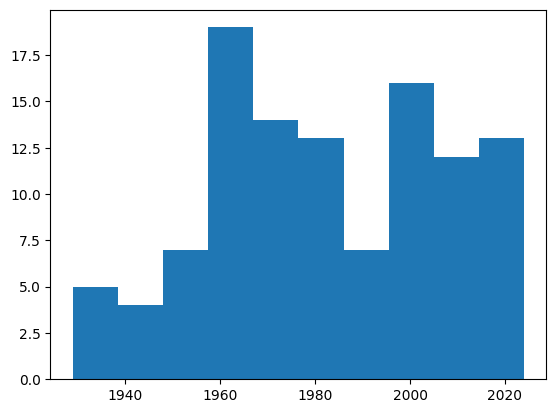

In [28]:
plt.hist(patients["year_of_birth"])